# Experiment A: Gating Stress Test

**Goal:** Train a transformer (Enhanced or Level2) on clean DMD data, then stress-test the gating mechanism under synthetic occlusion.

**Pipeline:**
1. Extract features from DMD frames + stratified train/val/test split
2. Train the selected transformer architecture from scratch
3. Stress test: apply synthetic occlusion to test frames, compare gating ON vs OFF

In [1]:
import os
# Avoid ONNX Runtime thread-affinity failures on HPC (pthread_setaffinity_np)
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OMP_WAIT_POLICY'] = 'PASSIVE'

import sys, time, warnings, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Imports ready.')

Device: cpu
Imports ready.


In [2]:
# ===========================  CONFIG  ===========================
#  'enhanced'  ->  EnhancedOcclusionAwareTransformer
#  'level2'    ->  Level2DynamicOcclusionAwareTransformer

MODEL_TYPE = 'enhanced'

# Frame sampling: set to 100 for CPU quick test, None for full GPU run
NUM_SAMPLES_PER_VIDEO = 100 if device.type == 'cpu' else None

NUM_EPOCHS       = 20
LEARNING_RATE    = 3e-5
BATCH_SIZE       = 32
HIDDEN_DIM       = 128
NUM_HEADS        = 4
NUM_LAYERS       = 3
MAX_PER_SUBJECT  = 30 if device.type == 'cpu' else None  # stress-test sampling

print(f'Model:            {MODEL_TYPE}')
print(f'Samples/video:    {NUM_SAMPLES_PER_VIDEO or "ALL"}')
print(f'Stress-test/subj: {MAX_PER_SUBJECT or "ALL"}')
print(f'Epochs:           {NUM_EPOCHS}')

Model:            enhanced
Samples/video:    100
Stress-test/subj: 30
Epochs:           20


In [3]:
import importlib
import occlusion_audit_utils, dofg_pipeline, synthetic_occlusion_utils
importlib.reload(occlusion_audit_utils)
importlib.reload(dofg_pipeline)
importlib.reload(synthetic_occlusion_utils)

from occlusion_audit_utils import (
    CONFIG, load_csv_video_data, FaceDetector,
    ResNet34OcclusionModel, sample_frames_for_audit,
)
from dofg_pipeline import (
    ResNet34FeatureExtractor,
    split_video_ids,
    extract_features_stratified,
)
from synthetic_occlusion_utils import apply_synthetic_occlusion, OPACITY_LEVELS

if MODEL_TYPE == 'enhanced':
    from dofg_pipeline import EnhancedOcclusionAwareTransformer as TransformerCls
elif MODEL_TYPE == 'level2':
    import level2_dynamic_transformer
    importlib.reload(level2_dynamic_transformer)
    from level2_dynamic_transformer import Level2DynamicOcclusionAwareTransformer as TransformerCls
else:
    raise ValueError(f'Unknown MODEL_TYPE: {MODEL_TYPE}')

print(f'Transformer: {TransformerCls.__name__}')

Transformer: EnhancedOcclusionAwareTransformer


## 1. Load Data & Models

In [4]:
csv_data = load_csv_video_data(CONFIG['CSV_DATASET_PATH'])

face_detector = FaceDetector(
    shape_model_path=CONFIG['DLIB_MODEL_PATH'],
    det_size=(640, 640), det_thresh=0.35,
)
occ_model = ResNet34OcclusionModel(
    CONFIG['RESNET34_OCCLUSION_MODEL_PATH'], device=str(device),
)
feat_extractor = ResNet34FeatureExtractor(
    CONFIG['RESNET34_MODEL_PATH'], device=str(device),
)
print('All models loaded.')

Loading CSV video data from: Data
  Sub1_sub1_video: 4256 frames (filtered 1224)
  Sub10_sub10_video: 4440 frames (filtered 1615)
  Sub11_sub11_video: 4049 frames (filtered 1328)
  Sub12_sub12_video: 4562 frames (filtered 1014)
  Sub13_sub13_video: 4246 frames (filtered 1134)
  Sub14_sub14_video: 4585 frames (filtered 929)
  Sub15_sub15_video: 3957 frames (filtered 1337)
  Sub2_sub2_video: 4218 frames (filtered 1198)
  Sub3_sub3_video: 3463 frames (filtered 2064)
  Sub4_sub4_video: 3829 frames (filtered 1400)
  Sub5_sub5_video: 3642 frames (filtered 1645)
  Sub6_sub6_video: 4031 frames (filtered 1379)
  Sub7_sub7_video: 3708 frames (filtered 1697)
  Sub8_sub8_video: 4345 frames (filtered 1062)
  Sub9_sub9_video: 3977 frames (filtered 1315)
Initializing RetinaFace detector...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mehaksaleem/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied pro

## 2. Extract Features + Stratified Split

Same strategy as `IV_notebook_journal_extension.ipynb`:
- 5 test videos selected with `seed=42`
- Remaining train-subject frames split 80/20 stratified by class
- Cached to `dmd_features_cache.pt` for reuse

In [6]:
splits = split_video_ids(csv_data, num_test=5, num_val=0, seed=42)
print(f'Train videos: {splits["train"]}')
print(f'Test  videos: {splits["test"]}')

train_csv = {k: v for k, v in csv_data.items() if k in splits['train']}
print(f'\nTrain-only CSV: {len(train_csv)} videos (test subjects skipped for feature extraction)')

Train videos: ['Sub7_sub7_video', 'Sub15_sub15_video', 'Sub12_sub12_video', 'Sub4_sub4_video', 'Sub13_sub13_video', 'Sub14_sub14_video', 'Sub6_sub6_video', 'Sub10_sub10_video', 'Sub11_sub11_video', 'Sub5_sub5_video']
Test  videos: ['Sub3_sub3_video', 'Sub8_sub8_video', 'Sub2_sub2_video', 'Sub1_sub1_video', 'Sub9_sub9_video']


In [7]:
suffix = f'_{NUM_SAMPLES_PER_VIDEO}' if NUM_SAMPLES_PER_VIDEO else '_all'
CACHE_PATH = f'dmd_train_features_cache{suffix}.pt'

if os.path.exists(CACHE_PATH):
    print(f'Loading cached features from {CACHE_PATH} ...')
    cache = torch.load(CACHE_PATH, weights_only=False)
    train_samples, val_samples = cache['train'], cache['val']
else:
    print(f'Extracting TRAIN features only (num_samples_per_video={NUM_SAMPLES_PER_VIDEO or "ALL"}) ...')
    train_samples, val_samples, _ = extract_features_stratified(
        train_csv, splits,
        face_detector=face_detector,
        feat_extractor=feat_extractor,
        occ_model=occ_model,
        num_samples_per_video=NUM_SAMPLES_PER_VIDEO,
        val_ratio=0.20,
        random_state=42,
    )
    torch.save({'train': train_samples, 'val': val_samples}, CACHE_PATH)
    print(f'Saved to {CACHE_PATH}')

print(f'\nTrain: {len(train_samples)}  Val: {len(val_samples)}')
for name, ss in [('Train', train_samples), ('Val', val_samples)]:
    dist = Counter(s['class_name'] for s in ss)
    print(f'  {name}: {dict(dist)}')

Extracting features (num_samples_per_video=100) ...
  Sub1_sub1_video [TEST]: 100 ok, 0 skipped
  Sub10_sub10_video [TRAIN]: 100 ok, 0 skipped
  Sub11_sub11_video [TRAIN]: 100 ok, 0 skipped
  Sub12_sub12_video [TRAIN]: 100 ok, 0 skipped
  Sub13_sub13_video [TRAIN]: 100 ok, 0 skipped
  Sub14_sub14_video [TRAIN]: 100 ok, 0 skipped
  Sub15_sub15_video [TRAIN]: 100 ok, 0 skipped
  Sub2_sub2_video [TEST]: 100 ok, 0 skipped
  Sub3_sub3_video [TEST]: 100 ok, 0 skipped
  Sub4_sub4_video [TRAIN]: 100 ok, 0 skipped
  Sub5_sub5_video [TRAIN]: 100 ok, 0 skipped
  Sub6_sub6_video [TRAIN]: 100 ok, 0 skipped
  Sub7_sub7_video [TRAIN]: 100 ok, 0 skipped
  Sub8_sub8_video [TEST]: 100 ok, 0 skipped
  Sub9_sub9_video [TEST]: 100 ok, 0 skipped
  Train: 800 samples  {'Neutral': 622, 'Yawn': 94, 'EyeClosed': 84}
  Val: 200 samples  {'Neutral': 156, 'EyeClosed': 21, 'Yawn': 23}
  Test: 500 samples  {'Neutral': 368, 'EyeClosed': 68, 'Yawn': 64}
Saved to dmd_features_cache_100.pt

Train: 800  Val: 200  Test: 5

## 3. DataLoaders

In [8]:
class DriverStateDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        features = {k: torch.tensor(v, dtype=torch.float32) for k, v in s['features'].items()}
        occ = s['occlusion_info'].copy()
        label = torch.tensor(s['label'], dtype=torch.long)
        occ_tgt = torch.tensor([occ['eye_occlusion_prob'], occ['mouth_occlusion_prob']], dtype=torch.float32)
        return {'features': features, 'occlusion_info': occ, 'label': label,
                'occlusion_targets': occ_tgt, 'class_name': s['class_name'],
                'frame_id': s['frame_id'], 'ground_truth': s['ground_truth']}


def collate_fn(batch):
    regions = batch[0]['features'].keys()
    return {
        'features': {r: torch.stack([b['features'][r] for b in batch]) for r in regions},
        'occlusion_info': {
            'eye_occlusion_prob': torch.tensor([b['occlusion_info']['eye_occlusion_prob'] for b in batch], dtype=torch.float32),
            'mouth_occlusion_prob': torch.tensor([b['occlusion_info']['mouth_occlusion_prob'] for b in batch], dtype=torch.float32),
        },
        'label': torch.stack([b['label'] for b in batch]),
        'occlusion_targets': torch.stack([b['occlusion_targets'] for b in batch]),
        'class_name': [b['class_name'] for b in batch],
        'frame_id': torch.tensor([b['frame_id'] for b in batch]),
        'ground_truth': [b['ground_truth'] for b in batch],
    }


train_loader = DataLoader(DriverStateDataset(train_samples), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(DriverStateDataset(val_samples),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f'Batches  Train: {len(train_loader)}  Val: {len(val_loader)}')

Batches  Train: 25  Val: 7  Test: 16


## 4. Initialise & Train

In [9]:
transformer = TransformerCls(
    feature_dim=512, hidden_dim=HIDDEN_DIM, num_heads=NUM_HEADS,
    num_classes=3, num_layers=NUM_LAYERS, use_relative_pos=True,
).to(device)

print(f'Model: {type(transformer).__name__}  |  Params: {sum(p.numel() for p in transformer.parameters()):,}')

Model: EnhancedOcclusionAwareTransformer  |  Params: 935,878


In [10]:
def move_batch(batch, dev):
    def to_dev(x):
        if isinstance(x, torch.Tensor):
            return x.float().to(dev) if x.is_floating_point() else x.to(dev)
        if isinstance(x, dict):
            return {k: to_dev(v) for k, v in x.items()}
        if isinstance(x, (float, int)):
            return torch.tensor(x, dtype=torch.float32, device=dev)
        return x
    return {k: to_dev(v) if k not in ('class_name', 'ground_truth') else v for k, v in batch.items()}


optimizer = torch.optim.AdamW(transformer.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    transformer.train()
    losses, correct, total = [], 0, 0
    for batch in train_loader:
        batch = move_batch(batch, device)
        optimizer.zero_grad(set_to_none=True)
        out = transformer(batch['features'], batch['occlusion_info'])
        loss = criterion(out['class_logits'], batch['label'])
        loss = loss - 0.01 * torch.var(out['gate_factors'], dim=1).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
        correct += (out['predicted_class'].view(-1) == batch['label'].view(-1)).sum().item()
        total += batch['label'].size(0)
    scheduler.step()
    t_loss, t_acc = np.mean(losses), correct / max(total, 1) * 100

    transformer.eval()
    vc, vt = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            batch = move_batch(batch, device)
            o = transformer(batch['features'], batch['occlusion_info'])
            vc += (o['predicted_class'].view(-1) == batch['label'].view(-1)).sum().item()
            vt += batch['label'].size(0)
    v_acc = vc / max(vt, 1) * 100

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    tag = ''
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        ckpt = f'exp_a_{MODEL_TYPE}_best.pt'
        torch.save(transformer, ckpt)
        tag = f'  ** saved'

    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f'Ep {epoch+1:3d}/{NUM_EPOCHS}: loss={t_loss:.4f}  train={t_acc:.1f}%  val={v_acc:.1f}%{tag}')

print(f'\nBest val: {best_val_acc:.1f}%')

Ep   1/20: loss=0.7935  train=70.6%  val=78.0%  ** saved
Ep   2/20: loss=0.6607  train=77.8%  val=78.0%
Ep   4/20: loss=0.4512  train=83.4%  val=89.5%  ** saved
Ep   6/20: loss=0.3238  train=88.8%  val=91.5%  ** saved
Ep   8/20: loss=0.2647  train=91.4%  val=93.5%  ** saved
Ep  10/20: loss=0.2668  train=92.6%  val=94.5%  ** saved
Ep  12/20: loss=0.2425  train=92.1%  val=94.5%
Ep  14/20: loss=0.2004  train=93.5%  val=95.5%  ** saved
Ep  16/20: loss=0.1954  train=94.1%  val=95.5%
Ep  18/20: loss=0.1940  train=94.2%  val=95.5%
Ep  20/20: loss=0.1824  train=93.9%  val=95.5%

Best val: 95.5%


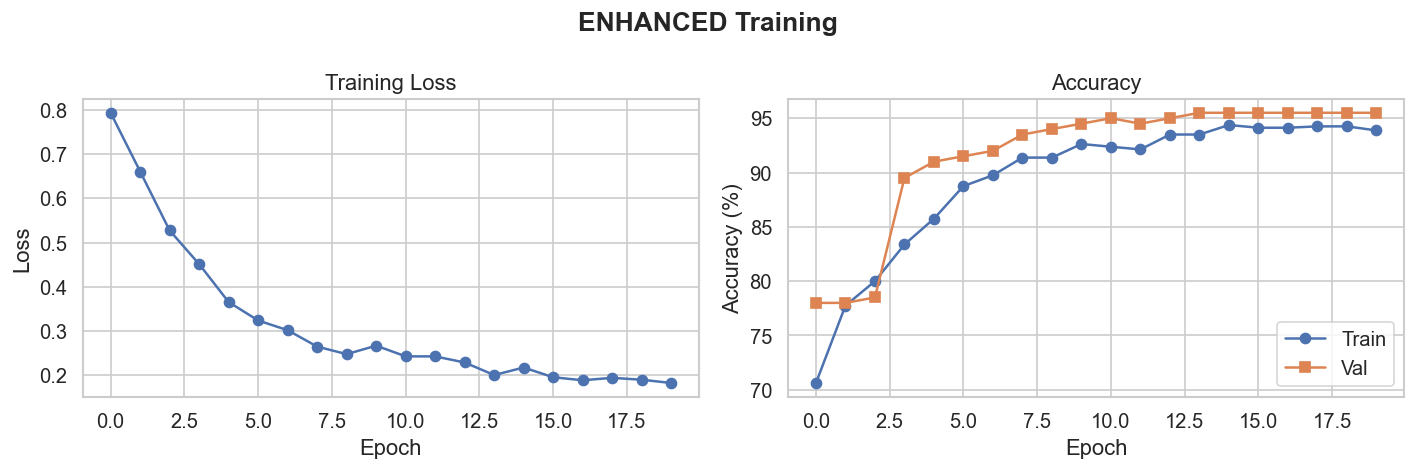

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], 'o-'); ax1.set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
ax2.plot(history['train_acc'], 'o-', label='Train'); ax2.plot(history['val_acc'], 's-', label='Val')
ax2.set(xlabel='Epoch', ylabel='Accuracy (%)', title='Accuracy'); ax2.legend()
fig.suptitle(f'{MODEL_TYPE.upper()} Training', fontweight='bold')
plt.tight_layout(); plt.savefig(f'exp_a_{MODEL_TYPE}_training.png', bbox_inches='tight'); plt.show()

In [12]:
# Load best checkpoint for stress-testing
ckpt = f'exp_a_{MODEL_TYPE}_best.pt'
transformer = torch.load(ckpt, map_location=device, weights_only=False)
transformer.to(device); transformer.eval()
print(f'Loaded {ckpt}')
print('Clean test accuracy will be computed from the stress-test "none" condition below.')

Loaded exp_a_enhanced_best.pt
Test accuracy (clean): 92.0%


## 5. Gating Helper

In [13]:
def run_with_gating_disabled(model, features, occlusion_info):
    if hasattr(model, 'compute_dynamic_gates'):
        orig = model.compute_dynamic_gates
        def _off(rf, oi, bs, dev):
            return torch.ones(bs, 4, device=dev), {
                'content':[], 'cross_region':[], 'occlusion_refined':[],
                'bounds':(1.,1.), 'temperature':1.}
        model.compute_dynamic_gates = _off
        try:
            return model(features, occlusion_info, return_attention=True)
        finally:
            model.compute_dynamic_gates = orig
    else:
        return model(features, occlusion_info, return_attention=True, disable_gating=True)

_df = {r: torch.randn(1,512).to(device) for r in ['face','left_eye','right_eye','mouth']}
_oi = {'eye_occlusion_prob': .5, 'mouth_occlusion_prob': .5}
with torch.no_grad():
    g_on  = transformer(_df, _oi)['gate_factors'].squeeze().cpu().numpy()
    g_off = run_with_gating_disabled(transformer, _df, _oi)['gate_factors'].squeeze().cpu().numpy()
print(f'ON  gates: {g_on.round(3)}')
print(f'OFF gates: {g_off.round(3)}')
del _df, _oi

ON  gates: [1.    0.655 0.655 0.614]
OFF gates: [1. 1. 1. 1.]


## 6. Stress Test: Synthetic Occlusion on Test Subjects

In [14]:
test_csv = {k: v for k, v in csv_data.items() if k in splits['test']}
sampled = sample_frames_for_audit(
    test_csv, max_per_subject=MAX_PER_SUBJECT, include_all_occluded=True, seed=42,
)
total_frames = sum(len(v) for v in sampled.values())
print(f'Stress-test: {total_frames} frames from {len(sampled)} videos')

  Sub1_sub1_video: 30 occluded + 0 non-occluded = 30 frames
  Sub2_sub2_video: 1 occluded + 29 non-occluded = 30 frames
  Sub3_sub3_video: 1 occluded + 29 non-occluded = 30 frames
  Sub8_sub8_video: 2 occluded + 28 non-occluded = 30 frames
  Sub9_sub9_video: 1 occluded + 29 non-occluded = 30 frames
Stress-test: 150 frames from 5 videos


In [15]:
LABEL_MAP = CONFIG['CSV_LABELS']
occlusion_configs = [
    ('none',       0.0, 0.0),
    ('eye_only',   1.0, 0.0),
    ('mouth_only', 0.0, 1.0),
    ('both',       1.0, 1.0),
]
opacity_levels = OPACITY_LEVELS

rows = []
total = sum(len(v) for v in sampled.values())
processed, skipped = 0, 0
t0 = time.time()

for video_key, ann_list in sampled.items():
    meta = csv_data[video_key]
    cap = cv2.VideoCapture(meta['video_path'])
    if not cap.isOpened(): continue
    subject = meta['subject']
    print(f'  {video_key} ({len(ann_list)} frames) ...')

    for ann in ann_list:
        cap.set(cv2.CAP_PROP_POS_FRAMES, ann.frame)
        ret, bgr = cap.read()
        if not ret: continue
        det = face_detector.detect_face_and_landmarks(bgr)
        if not det['is_valid']: skipped += 1; processed += 1; continue
        lm, fb, er, mr = det['landmarks'], det['face_bbox'], det['eye_regions'], det['mouth_region']
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        if ann.class_label not in LABEL_MAP: processed += 1; continue
        gt = LABEL_MAP[ann.class_label]

        for opacity in opacity_levels:
            for occ_name, eflag, mflag in occlusion_configs:
                if occ_name == 'none' and opacity > 0: continue
                if occ_name != 'none' and opacity == 0: continue
                eo = opacity if eflag else 0.0
                mo = opacity if mflag else 0.0

                aug_rgb = apply_synthetic_occlusion(rgb, lm, eye_opacity=eo, mouth_opacity=mo) if occ_name != 'none' else rgb
                aug_bgr = cv2.cvtColor(aug_rgb, cv2.COLOR_RGB2BGR) if occ_name != 'none' else bgr

                feat = feat_extractor.extract_region_features(aug_bgr, fb, er, mr)
                rkeys = ['face_features','left_eye_features','right_eye_features','mouth_features']
                if any(feat[k] is None for k in rkeys): continue
                fdict = {k.replace('_features',''): feat[k] for k in rkeys}
                # fix key names
                fdict = {'face': feat['face_features'], 'left_eye': feat['left_eye_features'],
                         'right_eye': feat['right_eye_features'], 'mouth': feat['mouth_features']}

                probs = occ_model.predict_probs(aug_rgb, face_bbox=fb, image_bgr=False, face_margin=0.15)
                occ_info = {'eye_occlusion_prob': float(probs[0]), 'mouth_occlusion_prob': float(probs[1])}

                with torch.no_grad():
                    out_on  = transformer(fdict, occ_info, return_attention=True)
                    out_off = run_with_gating_disabled(transformer, fdict, occ_info)
                gates = out_on['gate_factors'].squeeze().cpu().numpy()

                rows.append({
                    'subject': subject, 'frame': ann.frame,
                    'class_label': ann.class_label, 'gt_label': gt,
                    'occlusion_type': occ_name,
                    'opacity': opacity if occ_name != 'none' else 0.0,
                    'p_eye': float(probs[0]), 'p_mouth': float(probs[1]),
                    'pred_gating_on':  int(out_on['predicted_class'].item()),
                    'pred_gating_off': int(out_off['predicted_class'].item()),
                    'correct_gating_on':  int(out_on['predicted_class'].item() == gt),
                    'correct_gating_off': int(out_off['predicted_class'].item() == gt),
                    'gate_face': float(gates[0]), 'gate_eye': float(gates[1]), 'gate_mouth': float(gates[3]),
                })

        processed += 1
        if processed % 25 == 0:
            print(f'    [{processed}/{total}] {processed/(time.time()-t0):.1f} fr/s')
    cap.release()

print(f'\nDone: {processed} frames, {skipped} skipped, {time.time()-t0:.0f}s')
df = pd.DataFrame(rows)
df.to_csv(f'experiment_a_{MODEL_TYPE}_results.csv', index=False)
print(f'Saved {len(df)} rows')
df.head()

  Sub1_sub1_video (30 frames) ...
    [25/150] 0.6 fr/s
  Sub2_sub2_video (30 frames) ...
    [50/150] 0.6 fr/s
  Sub3_sub3_video (30 frames) ...
    [75/150] 0.6 fr/s
  Sub8_sub8_video (30 frames) ...
    [100/150] 0.7 fr/s
  Sub9_sub9_video (30 frames) ...
    [125/150] 0.7 fr/s
    [150/150] 0.7 fr/s

Done: 150 frames, 0 skipped, 229s
Saved 2400 rows


,subject,frame,class_label,gt_label,occlusion_type,opacity,p_eye,p_mouth,pred_gating_on,pred_gating_off,correct_gating_on,correct_gating_off,gate_face,gate_eye,gate_mouth
0,Sub1,117,Neutral,2,none,0.0,0.000399,0.000170,2,2,1,1,1.0,0.649859,0.650165
1,Sub1,117,Neutral,2,eye_only,0.3,0.046049,0.000677,2,2,1,1,1.0,0.650224,0.650179
2,Sub1,117,Neutral,2,mouth_only,0.3,0.000641,0.000684,2,2,1,1,1.0,0.649853,0.650179
3,Sub1,117,Neutral,2,both,0.3,0.061869,0.002470,2,2,1,1,1.0,0.650371,0.650098
4,Sub1,117,Neutral,2,eye_only,0.5,0.938979,0.000475,2,2,1,1,1.0,0.659386,0.650174


## 7. Results

In [16]:
print('=' * 70)
print(f'ACCURACY: GATING ON vs OFF  [{MODEL_TYPE.upper()}]')
print('=' * 70)

summary_rows = []
for ot in ['none', 'eye_only', 'mouth_only', 'both']:
    sub = df[df['occlusion_type'] == ot]
    if ot == 'none':
        n = len(sub)
        a_on, a_off = sub['correct_gating_on'].mean()*100, sub['correct_gating_off'].mean()*100
        print(f'\nNONE (n={n}): ON={a_on:.1f}%  OFF={a_off:.1f}%  d={a_on-a_off:+.1f}pp')
        summary_rows.append({'occ_type':ot,'opacity':0,'acc_on':a_on,'acc_off':a_off,'delta':a_on-a_off,'n':n})
    else:
        print(f'\n{ot.upper()}:')
        for op in sorted(sub['opacity'].unique()):
            ss = sub[sub['opacity']==op]
            a_on, a_off = ss['correct_gating_on'].mean()*100, ss['correct_gating_off'].mean()*100
            d = a_on-a_off
            m = ' ***' if d>2 else (' *' if d>.5 else '')
            print(f'  op={op:.1f}: ON={a_on:.1f}%  OFF={a_off:.1f}%  d={d:+.1f}pp (n={len(ss)}){m}')
            summary_rows.append({'occ_type':ot,'opacity':op,'acc_on':a_on,'acc_off':a_off,'delta':d,'n':len(ss)})

df_summary = pd.DataFrame(summary_rows)
df_summary

ACCURACY: GATING ON vs OFF  [ENHANCED]

NONE (n=150): ON=92.7%  OFF=82.7%  d=+10.0pp

EYE_ONLY:
  op=0.3: ON=93.3%  OFF=89.3%  d=+4.0pp (n=150) ***
  op=0.5: ON=92.7%  OFF=86.0%  d=+6.7pp (n=150) ***
  op=0.7: ON=88.0%  OFF=80.0%  d=+8.0pp (n=150) ***
  op=0.9: ON=71.3%  OFF=66.7%  d=+4.7pp (n=150) ***
  op=1.0: ON=41.3%  OFF=58.0%  d=-16.7pp (n=150)

MOUTH_ONLY:
  op=0.3: ON=90.7%  OFF=82.7%  d=+8.0pp (n=150) ***
  op=0.5: ON=87.3%  OFF=77.3%  d=+10.0pp (n=150) ***
  op=0.7: ON=82.0%  OFF=67.3%  d=+14.7pp (n=150) ***
  op=0.9: ON=77.3%  OFF=58.0%  d=+19.3pp (n=150) ***
  op=1.0: ON=71.3%  OFF=44.0%  d=+27.3pp (n=150) ***

BOTH:
  op=0.3: ON=91.3%  OFF=86.7%  d=+4.7pp (n=150) ***
  op=0.5: ON=89.3%  OFF=74.0%  d=+15.3pp (n=150) ***
  op=0.7: ON=78.0%  OFF=60.7%  d=+17.3pp (n=150) ***
  op=0.9: ON=34.0%  OFF=20.0%  d=+14.0pp (n=150) ***
  op=1.0: ON=18.0%  OFF=12.0%  d=+6.0pp (n=150) ***


,occ_type,opacity,acc_on,acc_off,delta,n
0,none,0.0,92.666667,82.666667,10.000000,150
1,eye_only,0.3,93.333333,89.333333,4.000000,150
2,eye_only,0.5,92.666667,86.000000,6.666667,150
3,eye_only,0.7,88.000000,80.000000,8.000000,150
4,eye_only,0.9,71.333333,66.666667,4.666667,150
5,eye_only,1.0,41.333333,58.000000,-16.666667,150
6,mouth_only,0.3,90.666667,82.666667,8.000000,150
7,mouth_only,0.5,87.333333,77.333333,10.000000,150
8,mouth_only,0.7,82.000000,67.333333,14.666667,150
9,mouth_only,0.9,77.333333,58.000000,19.333333,150


In [17]:
CN = {0:'EyeClosed', 1:'Yawn', 2:'Neutral'}
print(f'\nPER-CLASS at high opacity (>=0.9)  [{MODEL_TYPE.upper()}]')
for ot in ['eye_only','mouth_only','both']:
    sub = df[(df['occlusion_type']==ot) & (df['opacity']>=0.9)]
    print(f'  {ot.upper()} (n={len(sub)}):')
    for cid, cn in CN.items():
        cs = sub[sub['gt_label']==cid]
        if not len(cs): continue
        a_on, a_off = cs['correct_gating_on'].mean()*100, cs['correct_gating_off'].mean()*100
        print(f'    {cn:12s}: ON={a_on:.1f}%  OFF={a_off:.1f}%  d={a_on-a_off:+.1f}pp (n={len(cs)})')


PER-CLASS at high opacity (>=0.9)  [ENHANCED]
  EYE_ONLY (n=300):
    EyeClosed   : ON=47.4%  OFF=18.4%  d=+28.9pp (n=38)
    Yawn        : ON=78.1%  OFF=90.6%  d=-12.5pp (n=32)
    Neutral     : ON=54.8%  OFF=65.7%  d=-10.9pp (n=230)
  MOUTH_ONLY (n=300):
    EyeClosed   : ON=47.4%  OFF=10.5%  d=+36.8pp (n=38)
    Yawn        : ON=53.1%  OFF=75.0%  d=-21.9pp (n=32)
    Neutral     : ON=81.7%  OFF=54.3%  d=+27.4pp (n=230)
  BOTH (n=300):
    EyeClosed   : ON=13.2%  OFF=2.6%  d=+10.5pp (n=38)
    Yawn        : ON=68.8%  OFF=96.9%  d=-28.1pp (n=32)
    Neutral     : ON=22.2%  OFF=7.0%  d=+15.2pp (n=230)


## 8. Plots

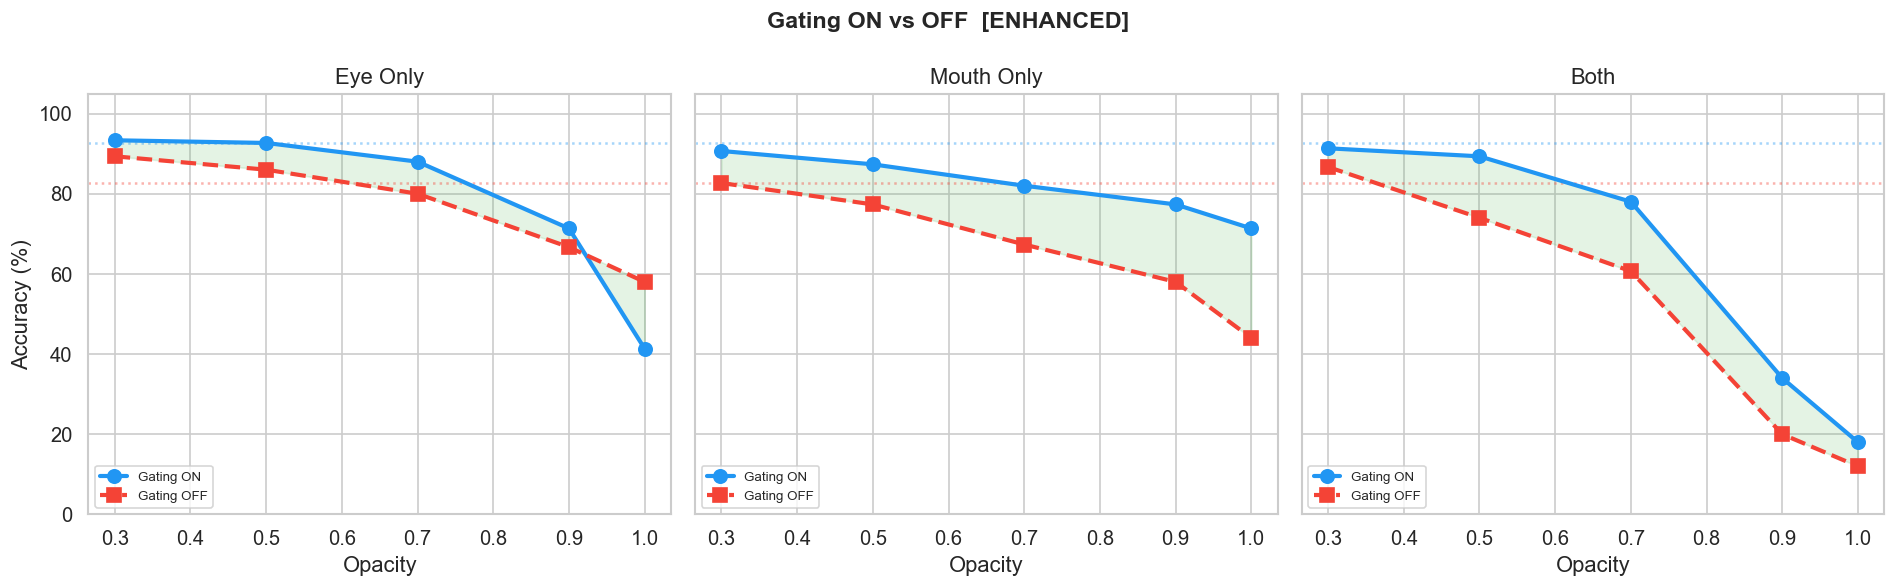

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
bl = df_summary[df_summary['occ_type']=='none']
bl_on, bl_off = (bl['acc_on'].values[0], bl['acc_off'].values[0]) if len(bl) else (0,0)

for ax, ot in zip(axes, ['eye_only','mouth_only','both']):
    s = df_summary[df_summary['occ_type']==ot]
    ax.plot(s['opacity'], s['acc_on'], 'o-', color='#2196F3', lw=2.5, ms=8, label='Gating ON', zorder=3)
    ax.plot(s['opacity'], s['acc_off'], 's--', color='#F44336', lw=2.5, ms=8, label='Gating OFF', zorder=3)
    ax.axhline(bl_on, color='#2196F3', ls=':', alpha=.4); ax.axhline(bl_off, color='#F44336', ls=':', alpha=.4)
    ax.fill_between(s['opacity'], s['acc_off'], s['acc_on'], alpha=.15, color='#4CAF50')
    ax.set(xlabel='Opacity', title=ot.replace('_',' ').title(), ylim=(0,105))
    ax.legend(fontsize=8, loc='lower left')
axes[0].set_ylabel('Accuracy (%)')
fig.suptitle(f'Gating ON vs OFF  [{MODEL_TYPE.upper()}]', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(f'exp_a_{MODEL_TYPE}_accuracy.png', bbox_inches='tight'); plt.show()

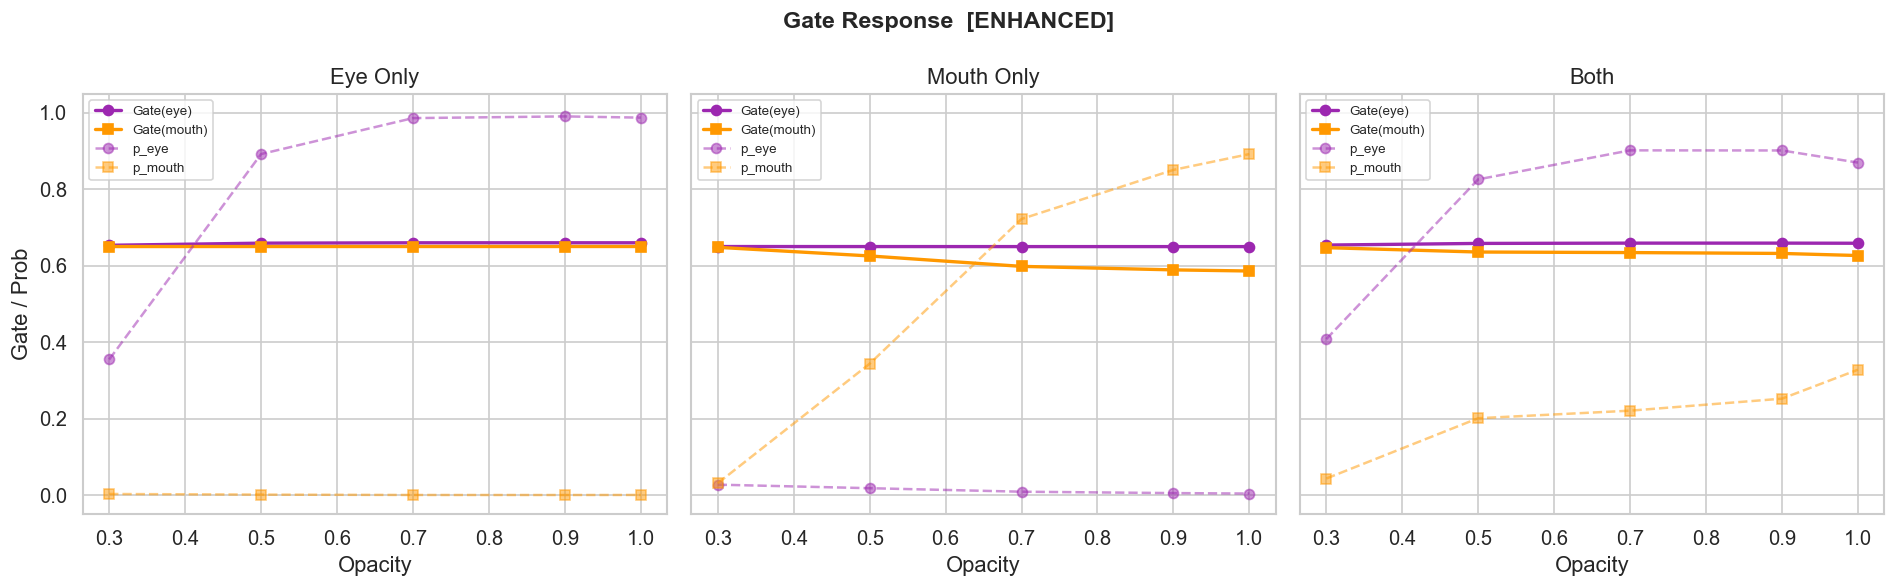

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, ot in zip(axes, ['eye_only','mouth_only','both']):
    s = df[df['occlusion_type']==ot].groupby('opacity').agg(
        gate_eye=('gate_eye','mean'), gate_mouth=('gate_mouth','mean'),
        p_eye=('p_eye','mean'), p_mouth=('p_mouth','mean')).reset_index()
    ax.plot(s['opacity'], s['gate_eye'], 'o-', color='#9C27B0', lw=2, label='Gate(eye)')
    ax.plot(s['opacity'], s['gate_mouth'], 's-', color='#FF9800', lw=2, label='Gate(mouth)')
    ax.plot(s['opacity'], s['p_eye'], 'o--', color='#9C27B0', alpha=.5, lw=1.5, label='p_eye')
    ax.plot(s['opacity'], s['p_mouth'], 's--', color='#FF9800', alpha=.5, lw=1.5, label='p_mouth')
    ax.set(xlabel='Opacity', title=ot.replace('_',' ').title(), ylim=(-.05,1.05))
    ax.legend(fontsize=8)
axes[0].set_ylabel('Gate / Prob')
fig.suptitle(f'Gate Response  [{MODEL_TYPE.upper()}]', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(f'exp_a_{MODEL_TYPE}_gates.png', bbox_inches='tight'); plt.show()

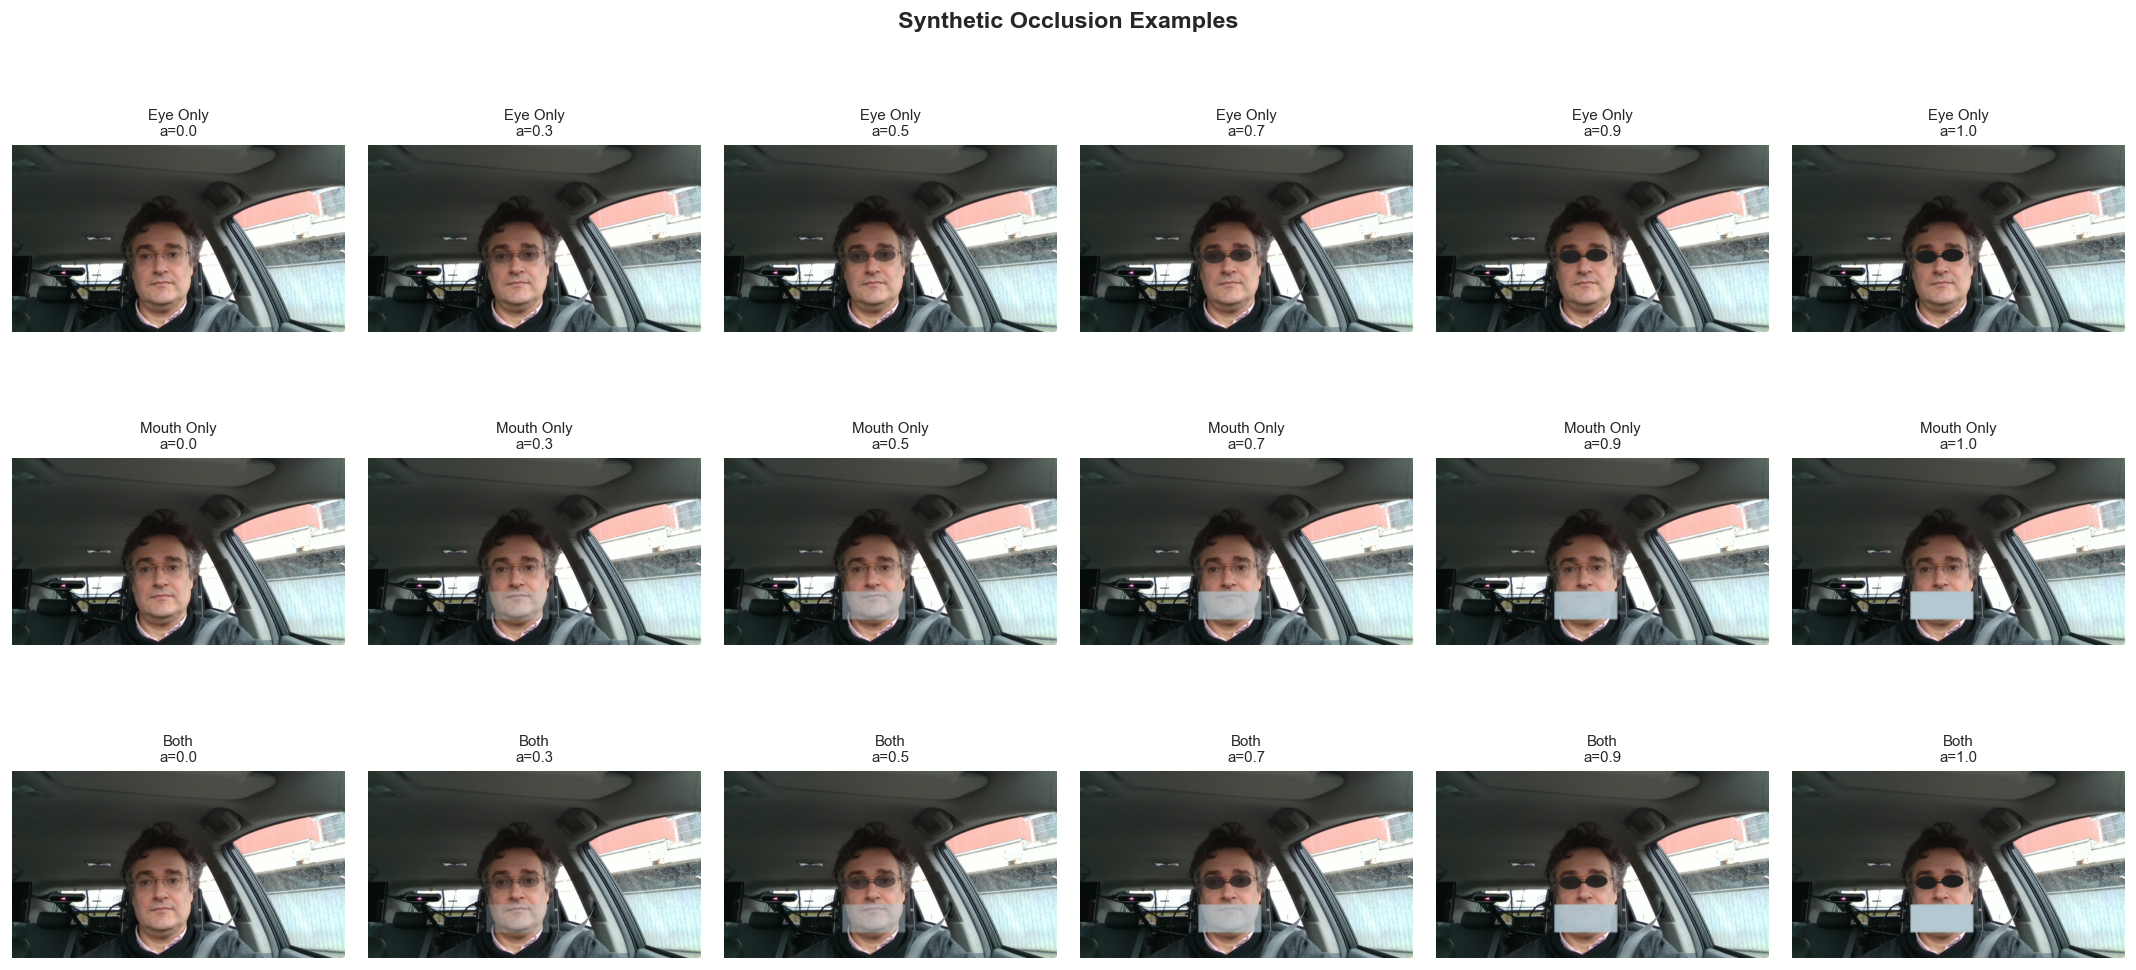

In [20]:
vis_key = list(sampled.keys())[0]
cap = cv2.VideoCapture(csv_data[vis_key]['video_path'])
cap.set(cv2.CAP_PROP_POS_FRAMES, sampled[vis_key][0].frame)
_, vb = cap.read(); cap.release()
vd = face_detector.detect_face_and_landmarks(vb)
vr, vl = cv2.cvtColor(vb, cv2.COLOR_BGR2RGB), vd['landmarks']

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for r, (t, ef, mf) in enumerate([
    ('Eye Only', lambda o:o, lambda o:0.), ('Mouth Only', lambda o:0., lambda o:o), ('Both', lambda o:o, lambda o:o)]):
    for c, op in enumerate([0,.3,.5,.7,.9,1.]):
        img = apply_synthetic_occlusion(vr, vl, eye_opacity=ef(op), mouth_opacity=mf(op)) if op>0 else vr
        axes[r,c].imshow(img); axes[r,c].axis('off'); axes[r,c].set_title(f'{t}\na={op:.1f}', fontsize=9)
fig.suptitle('Synthetic Occlusion Examples', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(f'exp_a_{MODEL_TYPE}_visual.png', bbox_inches='tight'); plt.show()

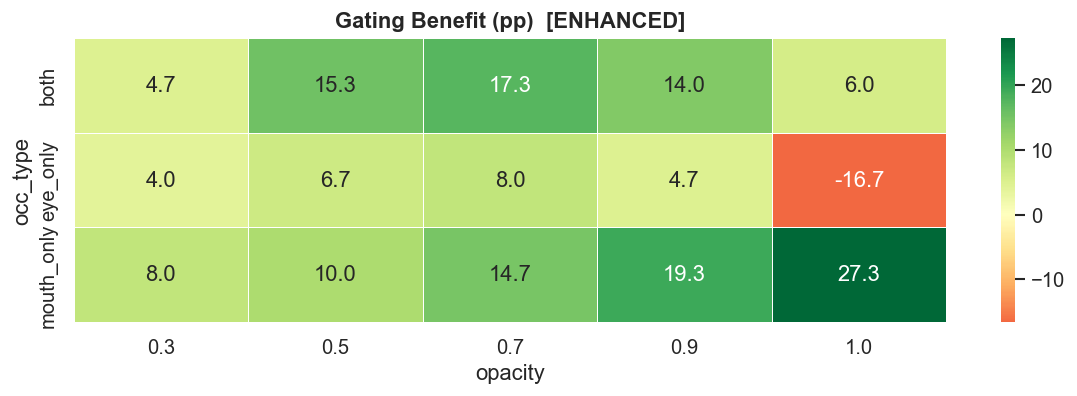

In [21]:
pivot = df_summary[df_summary['occ_type']!='none'].pivot(index='occ_type', columns='opacity', values='delta')
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0, linewidths=.5, ax=ax)
ax.set_title(f'Gating Benefit (pp)  [{MODEL_TYPE.upper()}]', fontweight='bold')
plt.tight_layout(); plt.savefig(f'exp_a_{MODEL_TYPE}_heatmap.png', bbox_inches='tight'); plt.show()

In [ ]:
# --- Visualise synthetic occlusion on random frames from random subjects ---
import random as _rnd

_rnd.seed(42)
np.random.seed(42)

n_subjects = min(4, len(sampled))
n_opacities = 4                            # columns: original + 3 opacity levels
vis_opacities = [0.0, 0.5, 0.7, 1.0]
occ_types = [
    ('Eye',   lambda o: o, lambda o: 0.0),
    ('Mouth', lambda o: 0.0, lambda o: o),
    ('Both',  lambda o: o, lambda o: o),
]

chosen_keys = _rnd.sample(list(sampled.keys()), n_subjects)
n_rows = n_subjects * len(occ_types)
fig, axes = plt.subplots(n_rows, n_opacities, figsize=(3.5 * n_opacities, 3 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

row = 0
for vk in chosen_keys:
    subject = csv_data[vk]['subject']
    ann = _rnd.choice(sampled[vk])
    cap = cv2.VideoCapture(csv_data[vk]['video_path'])
    cap.set(cv2.CAP_PROP_POS_FRAMES, ann.frame)
    ret, bgr = cap.read(); cap.release()
    if not ret:
        continue
    det = face_detector.detect_face_and_landmarks(bgr)
    if not det['is_valid']:
        continue
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    lm = det['landmarks']

    for occ_label, eye_fn, mouth_fn in occ_types:
        for c, op in enumerate(vis_opacities):
            if op == 0:
                img = rgb
            else:
                img = apply_synthetic_occlusion(rgb, lm,
                                                eye_opacity=eye_fn(op),
                                                mouth_opacity=mouth_fn(op))
            axes[row, c].imshow(img)
            axes[row, c].axis('off')
            if c == 0:
                axes[row, c].set_title(f'{subject} | {occ_label}\nOriginal', fontsize=8)
            else:
                axes[row, c].set_title(f'opacity={op:.1f}', fontsize=8)
        row += 1

fig.suptitle('Synthetic Occlusion: Random Frames from Random Subjects',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'exp_a_{MODEL_TYPE}_random_subjects_visual.png', bbox_inches='tight')
plt.show()

## 9. Summary

In [23]:
print('=' * 70)
print(f'EXPERIMENT A SUMMARY  [{MODEL_TYPE.upper()}]')
print('=' * 70)

b = df[df['occlusion_type']=='none']
h = df[(df['opacity']>=0.7) & (df['occlusion_type']!='none')]

b_on  = b['correct_gating_on'].mean()  * 100
b_off = b['correct_gating_off'].mean() * 100
h_on  = h['correct_gating_on'].mean()  * 100
h_off = h['correct_gating_off'].mean() * 100

n_frames = df[['subject','frame']].drop_duplicates().shape[0]
n_subjects = df['subject'].nunique()

print(f'\n--- Clean Test Accuracy (no synthetic occlusion) ---')
print(f'  Gating ON  : {b_on:.1f}%')
print(f'  Gating OFF : {b_off:.1f}%')
print(f'  Benefit    : {b_on - b_off:+.1f}pp')
print(f'  (evaluated on {len(b)} frames from {n_subjects} test subjects)')

print(f'\n--- Under Heavy Occlusion (opacity >= 0.7) ---')
print(f'  Gating ON  : {h_on:.1f}%')
print(f'  Gating OFF : {h_off:.1f}%')
print(f'  Benefit    : {h_on - h_off:+.1f}pp')

print(f'\n--- Accuracy Drop from Clean to Heavy Occlusion ---')
print(f'  Gating ON  : {b_on:.1f}% -> {h_on:.1f}%  (drop {b_on - h_on:.1f}pp)')
print(f'  Gating OFF : {b_off:.1f}% -> {h_off:.1f}%  (drop {b_off - h_off:.1f}pp)')

mx = df_summary.loc[df_summary['delta'].idxmax()]
print(f'\nMax gating benefit: {mx["occ_type"]} at opacity={mx["opacity"]:.1f} -> {mx["delta"]:+.1f}pp')
print(f'Total: {len(df)} rows | {n_frames} unique frames | {n_subjects} test subjects')

EXPERIMENT A SUMMARY  [ENHANCED]

Baseline:  ON=92.7%  OFF=82.7%
High occ:  ON=62.4%  OFF=51.9%
Benefit:   +10.5pp
Max:       mouth_only op=1.0 -> +27.3pp
Rows: 2400 | Frames: 150
